# GPU Example: Planetary Gaps

**This is the GPU-enabled version of the standard DustPy planetary-gap example. The simulation uses the CuPy backend while preserving the original physical model.**

In this example we demonstrate how to add gaps carved by planets into the gas.  
There are in principal three ways to achieve this: setting the gas surface density to the desired gap profile and not evolving it, adding torques to the gas evolution, or changing the viscosity.  
In this example we focus on adding a torque profile.

The torque profile that is needed to impose a gap on the gas is given by [Lau (2024)](https://doi.org/10.5282/edoc.34472):

$\Large \Lambda = -\frac{3}{2} \nu \Omega_\mathrm{K} \left( \frac{1}{2f} - \frac{\partial \log f}{\partial \log r} - \frac{1}{2} \right)$,

where $\large f$ is the pertubation in the gas surface density

$\Large f = \frac{\Sigma_\mathrm{g} \left( r \right)}{\Sigma_0}$.

## Gap Profiles

Since we are not self-consistently creating gaps, we have to impose a known gap profile. In this demonstration we are using the numerical fits to hydrodynamical simulations found by [Kanagawa et al. (2017)](https://doi.org/10.1093/pasj/psx114):

$\Large \Sigma\mathrm{g} \left( r \right) = \begin{cases}
    \Sigma_\mathrm{min} & \text{for} \quad \left| r - a_\mathrm{p} \right| < \Delta r_1, \\
    \Sigma_\mathrm{gap}\left( r \right) & \text{for} \quad \Delta r_1 < \left| r - a_\mathrm{p} \right| < \Delta r_2, \\
    \Sigma_0 & \text{for} \quad \left| r - a_\mathrm{p} \right| > \Delta r_2,
\end{cases}$


where $\large a_\mathrm{p}$ is the semi-major axis of the planet and $\large \Sigma_0$ is the unperturbed surface density, and

$\Large \frac{\Sigma_\mathrm{gap}\left(r\right)}{\Sigma_0} = \frac{4}{\sqrt[4]{K'}}\ \frac{\left|r-a_\mathrm{p}\right|}{a_\mathrm{p}}\ -\ 0.32$

$\Large \Sigma_\mathrm{min} = \frac{\Sigma_0}{1\ +\ 0.04\ K}$

$\Large \Delta r_1 = \left( \frac{\Sigma_\mathrm{min}}{4\Sigma_0} + 0.08 \right)\ \sqrt[4]{K'}\ a_\mathrm{p}$

$\Large \Delta r_2 = 0.33\ \sqrt[4]{K'}\ a_\mathrm{p}$

$\Large K = \left( \frac{M_\mathrm{p}}{M_*} \right)^2 \left( \frac{H_\mathrm{p}}{a_\mathrm{p}} \right)^{-5} \alpha^{-1}$

$\Large K' = \left( \frac{M_\mathrm{p}}{M_*} \right)^2 \left( \frac{H_\mathrm{p}}{a_\mathrm{p}} \right)^{-3} \alpha^{-1}$

$\large M_\mathrm{p}$ and $\large M_*$ are the masses of the planet and the star, $\large H_\mathrm{p}$ the pressure scale height at the planet location, and $\large \alpha$ the viscosity parameter.

We therefore need to write a function that calculates the pertubation $\large f = \Sigma_\mathrm{g}\left(r\right)/\Sigma_0$.

**The gap-profile function uses the backend-neutral `xp` API, so it operates on NumPy arrays for the standalone plot and on CuPy arrays after the GPU Simulation is activated.**

In [1]:
import numpy as np
from simframe.backends.api import xp  # Backend-neutral array API; mapped to CuPy for the GPU simulation


def Kanagawa2017_gap_profile(r, a, q, h, alpha):
    """Function calculates the gap profile according Kanagawa et al. (2017).

    Parameters
    ----------
    r : array
        Radial grid
    a : float
        Semi-majo axis of planet
    q : float
        Planet-star mass ratio
    h : float
        Aspect ratio at planet location
    alpha : float
        alpha viscosity parameter

    Returns
    -------
    f : array
        Pertubation of surface density due to planet"""

    # Unperturbed return value
    ret = xp.ones_like(r)

    # Distance to planet (normalized)
    dist = xp.abs(r-a)/a

    K = q**2 / (h**5 * alpha) # K
    Kp = q**2 / (h**3 * alpha) # K prime
    Kp4 = Kp**(0.25) # Fourth root of K prime
    SigMin = 1. / (1 + 0.04*K) # Sigma minimum
    SigGap = 4 / Kp4 * dist - 0.32 # Sigma gap
    dr1 = (0.25*SigMin + 0.08) * Kp**0.25 # Delta r1
    dr2 = 0.33 * Kp**0.25 # Delta r2

    # Gap edges
    mask1 = (dr1 < dist) & (dist < dr2)
    ret = xp.where(mask1, SigGap, ret)
    # Gap center
    mask2 = dist < dr1
    ret = xp.where(mask2, SigMin, ret)

    return ret


A planet of $30$ Earth masses at $10$ AU and the following parameters would induce the following pertubation onto the gas surface density.

In [2]:
import dustpy.constants as c

rp = 10. * c.au
h = 0.05
q = 30. * c.M_earth / c.M_sun
alpha = 1.e-3

In [3]:
r = np.geomspace(1.e0, 1.e3, 1000) * c.au

In [4]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 150.

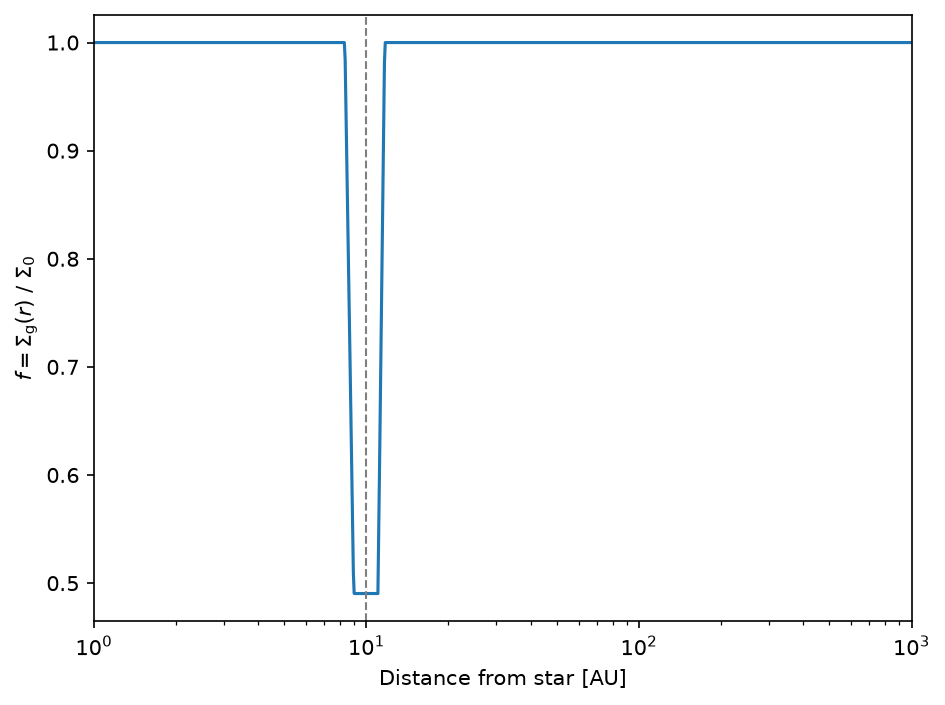

In [5]:
fig, ax = plt.subplots()
ax.semilogx(r/c.au, Kanagawa2017_gap_profile(r, rp, q, h, alpha))
ax.axvline(rp/c.au, ls="--", c="C7", lw=1)
ax.set_xlim(1., 1000.)
ax.set_xlabel("Distance from star [AU]")
ax.set_ylabel(r"$f = \Sigma_\mathrm{g} \left( r \right)\ /\ \Sigma_0$")
fig.set_layout_engine("tight")

## Adding planets

For this example we want to add two planets: Jupiter and Saturn. We therefore add new groups and subgroups to organize them.

In addition to that we want to refine the grid close to the planet locations. For this we use the function similar to the one discussed in an earlier chapter.

**Radial-grid construction remains a host-side setup operation, so `refinegrid` intentionally uses NumPy before `Simulation.initialize()`.**

In [6]:
def refinegrid(ri, r0, num=3):
    ind = np.argmin(r0 > ri) - 1
    indl = ind-num
    indr = ind+num+1
    ril = ri[:indl]
    rir = ri[indr:]
    N = (2*num+1)*2
    rim = np.empty(N)
    for i in range(0, N, 2):
        j = ind-num+int(i/2)
        rim[i] = ri[j]
        rim[i+1] = 0.5*(ri[j]+ri[j+1])
    return np.concatenate((ril, rim, rir))

In [7]:
from dustpy import Simulation
from dustpy.utils import to_numpy  # Transfer CuPy arrays to NumPy only for custom Matplotlib plots


In [8]:
sim = Simulation(backend="cupy")  # N.B.: use the CuPy backend for GPU acceleration

In [9]:
ri = np.geomspace(1.e0, 1.e3, 100) * c.au
ri = refinegrid(ri, 5.2*c.au)
ri = refinegrid(ri, 9.6*c.au)
sim.grid.ri = ri

In [10]:
sim.initialize()

In [11]:
sim.addgroup("planets")
sim.planets.addgroup("jupiter")
sim.planets.addgroup("saturn")

Group
-----

In [12]:
sim.planets.jupiter.addfield("a", 5.2*c.au, description="Semi-major axis [cm]")
sim.planets.jupiter.addfield("M", 1.*c.M_jup, description="Mass [g]")

1.8981245973360504e+30

In [13]:
sim.planets.saturn.addfield("a", 9.6*c.au, description="Semi-major axis [cm]")
sim.planets.saturn.addfield("M", 95*c.M_earth, description="Mass [g]")

5.67355947440181e+29

The planets are now set up.

In [14]:
sim.planets.toc

Group
    - jupiter: Group
        - a: Field (Semi-major axis [cm])
        - M: Field (Mass [g])
    - saturn: Group
        - a: Field (Semi-major axis [cm])
        - M: Field (Mass [g])


## Adding torque profile

We now have to write a funtion that returns the $\large \Lambda$ torque profile that imposes the desired gap profile onto the gas surface density from those two planets.

**The torque updater uses `xp.interp` and other backend-native operations so its per-cycle calculations remain on the GPU.**

In [15]:
def Lambda_torque(sim, return_profile=False):
    f = xp.ones_like(sim.grid.r)
    fi = xp.ones_like(sim.grid.ri)
    for name, planet in sim.planets:
        q = planet.M/sim.star.M
        h = xp.interp(planet.a, sim.grid.r, sim.gas.Hp/sim.grid.r)
        alpha = xp.interp(planet.a, sim.grid.r, sim.gas.alpha)
        f *= Kanagawa2017_gap_profile(sim.grid.r, planet.a, q, h, alpha)
        fi *= Kanagawa2017_gap_profile(sim.grid.ri, planet.a, q, h, alpha)
    grad = xp.log(fi[1:]/fi[:-1]) / xp.log(sim.grid.ri[1:]/sim.grid.ri[:-1])
    Lambda = -1.5 * sim.grid.OmegaK * sim.gas.nu * (1./(2.*f) - grad - 0.5)
    if return_profile:
        return Lambda, f
    return Lambda


This function now produces the $\large \alpha$ viscosity profile that creates planetary gaps in the gas surface density.

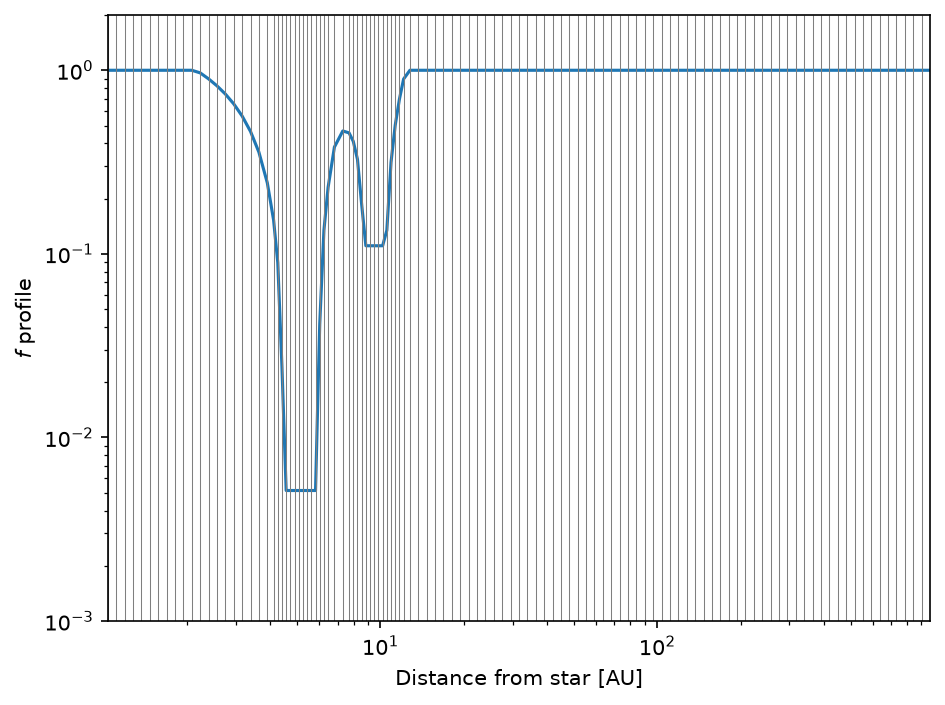

In [16]:
fig, ax = plt.subplots()
_, f = Lambda_torque(sim, return_profile=True)
r_au = to_numpy(sim.grid.r) / c.au
f_plot = to_numpy(f)
ax.loglog(r_au, f_plot)
ax.set_xlim(r_au[0], r_au[-1])
ax.set_ylim(1.e-3, 2.)
ax.vlines(r_au, 1.e-3, 2., lw=0.5, color="C7")
ax.set_xlabel("Distance from star [AU]")
ax.set_ylabel(r"$f$ profile")
fig.set_layout_engine("tight")


We could now assign this profile to the $\large \Lambda$ torque parameter.

In [17]:
sim.gas.torque.Lambda[:] = Lambda_torque(sim)

## Growing planets

Right now we could already start the simulation. But in this demonstration we want to let the planets grow linearly to their final mass. we therefore write a function that returns the planetary mass as a function of time.

In [18]:
def Mplan(t, tini, tfin, Mini, Mfin):
    """Function returns the planetary mass.
    
    Parameters
    ----------
    t : float
        Current time
    tini : float
        Time of start of growth phase
    tfin : float
        Time of end of growth phase
    Mini : float
        Initial planetary mass
    Mfin : float
        Final planetary mass"""
    if t<=tini:
        return Mini
    elif t>=tfin:
        return Mfin
    else:
        return (Mfin-Mini)/(tfin-tini)*(t-tini) + Mini

We want to start with planet masses of $1$ Earth mass and they should reach their final masses after $100\,000$ years. We have to write functions for each planet that returns their mass as a function of time.

In [19]:
def Mjup(sim):
    return Mplan(sim.t, 0., 1.e5*c.year, 1.*c.M_earth, 1.*c.M_jup)

def Msat(sim):
    return Mplan(sim.t, 0., 1.e5*c.year, 1.*c.M_earth, 95.*c.M_earth)

These functions have to be assigned to the updaters of their respective fields.

In [20]:
sim.planets.jupiter.M.updater.updater = Mjup
sim.planets.saturn.M.updater.updater = Msat

We also have to oragnize the update structure of the planets.

In [21]:
sim.planets.jupiter.updater = ["M"]
sim.planets.saturn.updater = ["M"]
sim.planets.updater = ["jupiter", "saturn"]

And we have to tell the main simulation frame to update the planets group. This has to be done before the gas quantities, since `Simulation.gas.alpha` needs to know the planetary masses. So we simply update it in the beginning.

In [22]:
sim.updater = ["planets", "star", "grid", "gas", "dust"]

Since the $\large \Lambda$ torque profile is not constant now, we have assign our $\Lambda$ function to its updater.

In [23]:
sim.gas.torque.Lambda.updater.updater = Lambda_torque

To bring the simulation frame into consistency we have to update it.

In [24]:
sim.update()

The planetary masses are now set to their initial values.

In [25]:
msg = "Masses\nJupiter: {:4.2f} M_earth\nSaturn:  {:4.2f} M_earth".format(sim.planets.jupiter.M/c.M_earth, sim.planets.saturn.M/c.M_earth)
print(msg)

Masses
Jupiter: 1.00 M_earth
Saturn:  1.00 M_earth


We can now start the simulation.

**`sim.run()` automatically reactivates this Simulation's CuPy backend before integration.**

In [26]:
sim.writer.datadir = "data/gpu_example_planetary_gaps"

In [27]:
sim.run()


DustPy-GPU v1.0.9.2 (based on DustPy v1.0.9)
Backend: cupy

Documentation (DustPy): https://stammler.github.io/dustpy/
PyPI (DustPy): https://pypi.org/project/dustpy/
GitHub (DustPy): https://github.com/stammler/dustpy/
GitHub (DustPy-GPU): https://github.com/astroboylrx/dustpy-gpu/
GPU examples: https://github.com/astroboylrx/dustpy-gpu/tree/master/gpu_examples

Please cite Stammler & Birnstiel (2022) for DustPy
and Li & Chiang (2026) for DustPy-GPU.

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.82e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  4.44e-16
        for particle collision
            m[32] =  3.73e-08 g    with
            m[38] =  2.68e-07 g
    - Erosion:
        max. rel. error:  1.78e-15
        for particle collision
            m[110] =  5.18e+03 g    with
            m[118] =  7.20e+04 g

Creating data directory data/gp

Writing dump file data/gpu_example_planetary_gaps/frame.dmp


Writing file data/gpu_example_planetary_gaps/data0001.hdf5


Writing dump file data/gpu_example_planetary_gaps/frame.dmp


Writing file data/gpu_example_planetary_gaps/data0002.hdf5


...

Writing file data/gpu_example_planetary_gaps/data0020.hdf5


Writing dump file data/gpu_example_planetary_gaps/frame.dmp


Writing file data/gpu_example_planetary_gaps/data0021.hdf5


Writing dump file data/gpu_example_planetary_gaps/frame.dmp


Execution time: 0:04:04


This is the result of our simulation.

**`plot.panel` accepts the CuPy-backed Simulation directly and performs the required device-to-host transfer internally.**

In [28]:
from dustpy import plot

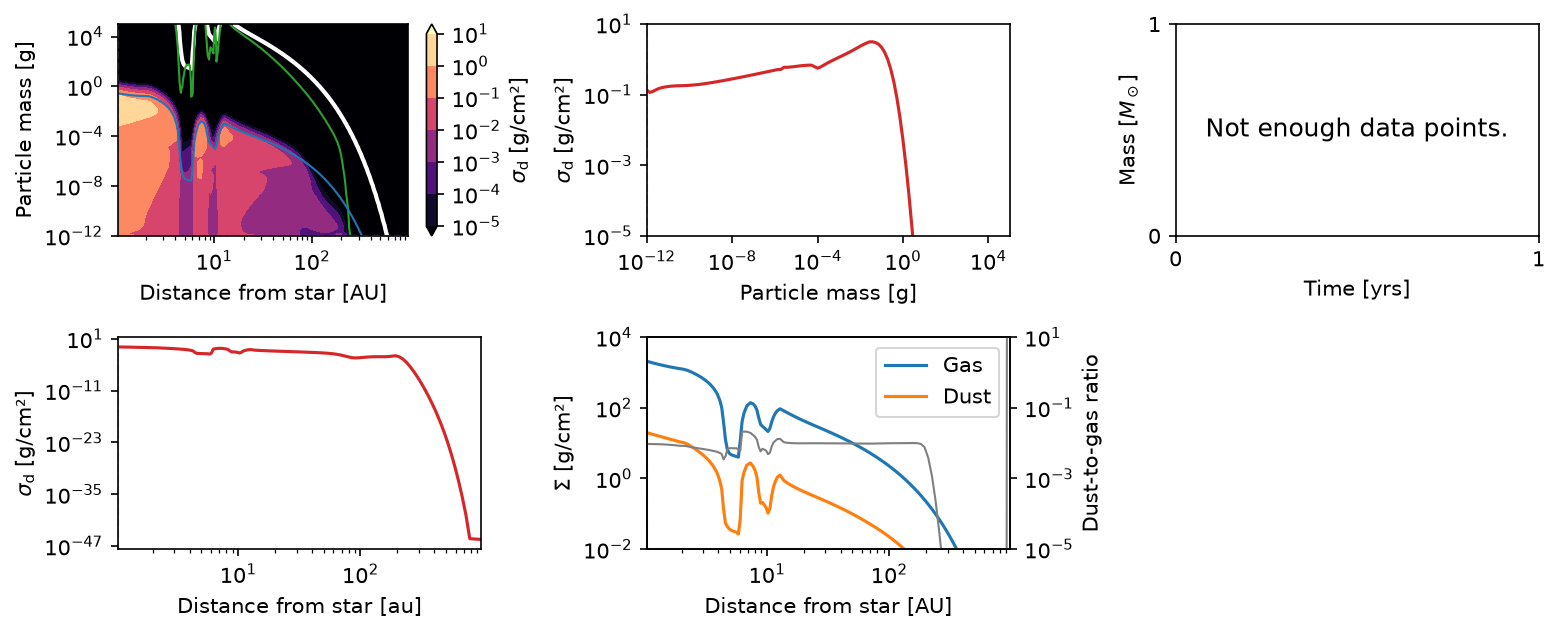

In [29]:
plot.panel(sim)

As can be seen, the core of Jupiter and Saturn carved gaps in the gas disk, which in turn affected the dust evolution.

To see that the planetary masses actually changed we can plot them over time.

**`sim.writer.read.sequence` returns host arrays from HDF5, so the final time-series plot needs no additional CuPy conversion.**

In [30]:
t = sim.writer.read.sequence("t")
Mjup = sim.writer.read.sequence("planets.jupiter.M")
Msat = sim.writer.read.sequence("planets.saturn.M")

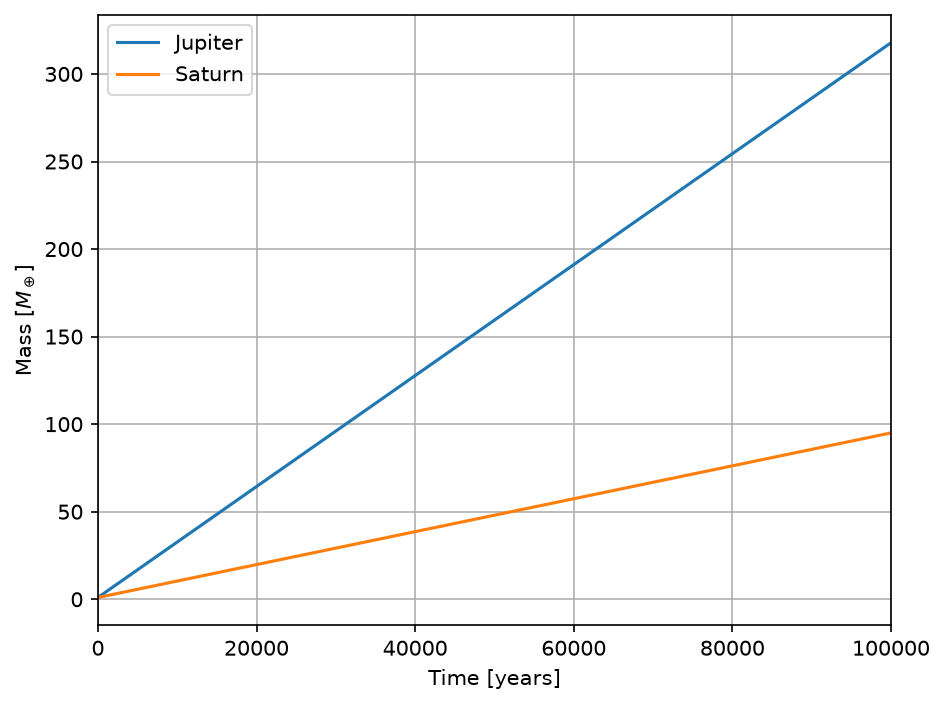

In [31]:
fig, ax = plt.subplots()
ax.plot(t/c.year, Mjup/c.M_earth, label="Jupiter")
ax.plot(t/c.year, Msat/c.M_earth, label="Saturn")
ax.legend()
ax.set_xlim(t[0]/c.year, t[-1]/c.year)
ax.grid(visible=True)
ax.set_xlabel(r"Time [years]")
ax.set_ylabel(r"Mass [$M_\oplus$]")
fig.set_layout_engine("tight")